# circle grid detection

Membaca gambar dari: E:\test mini xray\preprocessing\output-test-cal\Image_20260227151903366_calibrate_raw_processed.tiff
Mengonversi gambar dari uint16 ke uint8...
Mencari grid dengan ukuran (27, 18)...

=== GAGAL: Pola Circle Grid tidak terdeteksi secara utuh ===
Penyebab Umum: Ukuran grid_size tidak sesuai dengan jumlah baris/kolom penuh di gambar.

--- INFORMASI DEBUGGING RAW BLOB ---
Jumlah total titik (blob) putih yang terdeteksi di gambar: 486 titik
Sampel informasi 5 titik pertama yang terdeteksi secara acak:
  Blob 1 -> Koordinat: (X=1876.22, Y=1396.81), Diameter: 36.00 px
  Blob 2 -> Koordinat: (X=3327.14, Y=1078.63), Diameter: 35.70 px
  Blob 3 -> Koordinat: (X=919.78, Y=921.75), Diameter: 35.01 px
  Blob 4 -> Koordinat: (X=2517.39, Y=126.75), Diameter: 33.93 px
  Blob 5 -> Koordinat: (X=3166.24, Y=2360.67), Diameter: 33.65 px


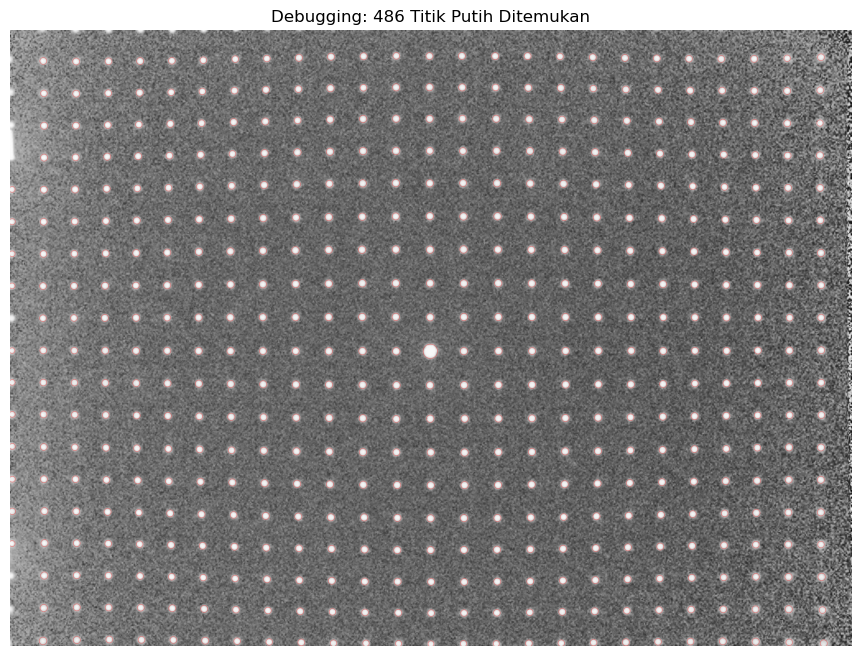

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def detect_circle_grid(image_path, grid_size=(27, 20), circle_diameter=40):
    # 1. Baca gambar
    print(f"Membaca gambar dari: {image_path}")
    # Gunakan IMREAD_UNCHANGED agar format TIFF (terutama 16-bit X-ray) terbaca utuh
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if img is None:
        print("Error: Gambar tidak ditemukan atau format tidak didukung.")
        return

    # Menangani gambar Grayscale (1 channel) atau Berwarna (3 channel)
    if len(img.shape) == 2:
        gray = img
        img_display = cv2.cvtColor(
            gray, cv2.COLOR_GRAY2BGR
        )  # Untuk menggambar hasil berwarna
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_display = img.copy()

    # SimpleBlobDetector biasanya butuh format 8-bit (uint8)
    # TIFF dari X-ray biasanya 16-bit, jadi perlu kita konversi ke 8-bit
    if gray.dtype != np.uint8:
        print(f"Mengonversi gambar dari {gray.dtype} ke uint8...")
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        img_display = cv2.normalize(
            img_display, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U
        )

    # 2. Atur Parameter SimpleBlobDetector
    params = cv2.SimpleBlobDetector_Params()

    # Filter berdasarkan warna (Sangat penting karena titiknya berwarna putih)
    params.filterByColor = True
    params.blobColor = 255  # 255 berarti mencari blob/titik terang (putih)

    # Menghitung area secara otomatis dari input diameter
    radius = circle_diameter / 2
    expected_area = np.pi * (radius**2)

    # Filter berdasarkan Area dengan toleransi
    # Toleransi besar diberikan (20% hingga 350%) agar titik tengah yang jauh lebih besar tetap terdeteksi
    params.filterByArea = True
    params.minArea = expected_area * 0.2
    params.maxArea = expected_area * 3.5

    # Filter berdasarkan Circularity (Bentuk seberapa bulat titiknya)
    params.filterByCircularity = True
    params.minCircularity = 0.7

    # Filter berdasarkan Convexity
    params.filterByConvexity = True
    params.minConvexity = 0.87

    # Filter berdasarkan Inertia
    params.filterByInertia = True
    params.minInertiaRatio = 0.5

    # Buat pendeteksi blob dengan parameter di atas
    detector = cv2.SimpleBlobDetector_create(params)

    # 3. Deteksi pola Circle Grid
    print(f"Mencari grid dengan ukuran {grid_size}...")

    # flag CALIB_CB_SYMMETRIC_GRID untuk grid berbentuk kotak/simetris
    flags = cv2.CALIB_CB_SYMMETRIC_GRID | cv2.CALIB_CB_CLUSTERING

    ret, centers = cv2.findCirclesGrid(
        gray, grid_size, flags=flags, blobDetector=detector
    )

    # 4. Tampilkan Hasil
    if ret:
        print("\n=== BERHASIL: Pola Circle Grid ditemukan! ===")
        print(f"Jumlah titik grid terdeteksi: {len(centers)} titik")
        print("Informasi 5 titik pertama (X, Y):")
        for i, pt in enumerate(centers[:5]):
            print(f"  Titik {i+1}: X={pt[0][0]:.2f}, Y={pt[0][1]:.2f}")

        # Gambar garis yang menghubungkan titik-titik tersebut
        img_result = cv2.drawChessboardCorners(
            img_display.copy(), grid_size, centers, ret
        )

        # Plot menggunakan Matplotlib
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
        plt.title(f"Deteksi Circle Grid (Simetris) - {grid_size[0]}x{grid_size[1]}")
        plt.axis("off")
        plt.show()
    else:
        print("\n=== GAGAL: Pola Circle Grid tidak terdeteksi secara utuh ===")
        print(
            "Penyebab Umum: Ukuran grid_size tidak sesuai dengan jumlah baris/kolom penuh di gambar."
        )

        # Debugging: Ambil informasi raw dari blob detector
        keypoints = detector.detect(gray)

        print("\n--- INFORMASI DEBUGGING RAW BLOB ---")
        print(
            f"Jumlah total titik (blob) putih yang terdeteksi di gambar: {len(keypoints)} titik"
        )

        if len(keypoints) > 0:
            print("Sampel informasi 5 titik pertama yang terdeteksi secara acak:")
            for i, kp in enumerate(keypoints[:5]):
                # kp.pt adalah (x, y), kp.size adalah diameter blob
                print(
                    f"  Blob {i+1} -> Koordinat: (X={kp.pt[0]:.2f}, Y={kp.pt[1]:.2f}), Diameter: {kp.size:.2f} px"
                )

        # Gambar blob yang terdeteksi
        img_debug = cv2.drawKeypoints(
            img_display.copy(),
            keypoints,
            np.array([]),
            (0, 0, 255),
            cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )

        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(img_debug, cv2.COLOR_BGR2RGB))
        plt.title(f"Debugging: {len(keypoints)} Titik Putih Ditemukan")
        plt.axis("off")
        plt.show()


# --- Bagian eksekusi (Cocok untuk 1 Cell di Jupyter Notebook / VS Code) ---

FILENAME = r"E:\test mini xray\preprocessing\output-test-cal\Image_20260227151903366_calibrate_raw_processed.tiff"

# KEMBALIKAN KE 27x20 AGAR BERHASIL, atau biarkan 10x10 untuk melihat output debugging
PATTERN_SIZE = (27, 18)

# Menjalankan fungsi deteksi
detect_circle_grid(FILENAME, grid_size=PATTERN_SIZE, circle_diameter=40)